# 05 · Análisis de resultados

Lee los resultados guardados por los notebooks 02 y 04 (no reentrena
nada) y construye las tablas/gráficas finales para el README y la
presentación: ¿mejora el predictor al añadir historia sintética?, ¿qué
generador funciona mejor?, ¿coincide con qué generador preserva mejor la
distribución conjunta real (notebook 02)?

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# Recarga automatica de src/ al editarlo: sin esto, si se edita un modulo
# de src/ con el kernel ya arrancado, Jupyter sigue usando la version que
# importo la primera vez (y aparecen errores tipo "unexpected keyword
# argument" con codigo que en disco si es correcto).
try:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")
except NameError:
    pass  # ejecutandose fuera de IPython/Jupyter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config, plotting as pl

## 1. Cargar resultados

In [2]:
results = pd.read_csv(config.TABLES_DIR / "04_resultados_rejilla_profundidad.csv")
corr_quality = pd.read_csv(config.TABLES_DIR / "02_calidad_correlacion_generadores.csv", index_col=0)
empalme = pd.read_csv(config.TABLES_DIR / "03_continuidad_empalme.csv", index_col=0)
results.head()

,Unnamed: 0,generator,synth_years,horizonte,n_train,pct_synth,mse,mae,directional_accuracy
0,0,solo_reales,0.0,1,1045,0.000000,0.00025,0.011764,0.520000
1,1,gan,1.0,1,1355,0.228782,0.00025,0.011773,0.510164
2,2,gaussian,1.0,1,1355,0.228782,0.00025,0.011773,0.510164
3,3,noise,1.0,1,1355,0.228782,0.00025,0.011773,0.512787
4,4,rbig,1.0,1,1355,0.228782,0.00025,0.011774,0.510164


## 2. Tabla final: MAE por generador y años de backfill sintético añadidos

`synth_years=0` es la referencia "solo reales": en ese punto los 4
generadores entrenan exactamente con los mismos datos (todavía no se ha
añadido ningún día sintético), así que comparten valor. Se construye la
tabla con esa fila replicada para las 4 columnas — en vez de dejar una
columna `solo_reales` suelta que solo tendría dato en la fila 0 y dejaría
el resto de la tabla lleno de huecos.

In [3]:
GENERADORES = [g for g in results["generator"].unique() if g != "solo_reales"]
baseline = results[results["generator"] == "solo_reales"].iloc[0]
baseline_mae = baseline["mae"]


def pivot_con_baseline(metric: str) -> pd.DataFrame:
    """Pivot (synth_years x generador) de `metric`, con la fila
    synth_years=0 rellenada con el valor de referencia 'solo reales' para
    los 4 generadores (en ese punto son el mismo modelo)."""
    piv = (
        results[results["generator"] != "solo_reales"]
        .pivot_table(index="synth_years", columns="generator", values=metric)
    )
    piv.loc[0] = baseline[metric]
    return piv.sort_index()[GENERADORES]


pivot_mae = pivot_con_baseline("mae")
pivot_dir = pivot_con_baseline("directional_accuracy")
mejora_pct = (baseline_mae - pivot_mae) / baseline_mae * 100

pivot_mae.to_csv(config.TABLES_DIR / "05_tabla_mae_final.csv")
pivot_dir.to_csv(config.TABLES_DIR / "05_tabla_precision_direccional.csv")
mejora_pct.to_csv(config.TABLES_DIR / "05_tabla_mejora_pct.csv")

print(
    "Referencia 'solo reales' (synth_years=0, ~4,6 años reales sin sintéticos): "
    f"MAE {baseline_mae:.5f} | precisión direccional {baseline['directional_accuracy']:.1%}"
)
pivot_mae.round(5)

Referencia 'solo reales' (synth_years=0, ~4,6 años reales sin sintéticos): MAE 0.01176 | precisión direccional 52.0%


generator,gan,gaussian,noise,rbig
synth_years,,,,
0.0,0.01176,0.01176,0.01176,0.01176
1.0,0.01177,0.01177,0.01177,0.01177
2.0,0.01180,0.01180,0.01180,0.01180
5.0,0.01176,0.01176,0.01176,0.01176
10.0,0.01176,0.01176,0.01176,0.01176
24.0,0.01178,0.01178,0.01178,0.01178


Mejora relativa del MAE frente a la referencia (positivo = mejor que
entrenar solo con datos reales):

In [4]:
mejora_pct.round(2)

generator,gan,gaussian,noise,rbig
synth_years,,,,
0.0,0.00,0.00,0.00,0.00
1.0,-0.08,-0.08,-0.07,-0.09
2.0,-0.30,-0.30,-0.29,-0.30
5.0,0.01,0.01,0.03,0.04
10.0,0.06,0.06,0.07,0.06
24.0,-0.11,-0.12,-0.12,-0.14


Precisión direccional (fracción de días con el signo del retorno
acertado; 0.5 = azar):

In [5]:
pivot_dir.round(4)

generator,gan,gaussian,noise,rbig
synth_years,,,,
0.0,0.5200,0.5200,0.5200,0.5200
1.0,0.5102,0.5102,0.5128,0.5102
2.0,0.4898,0.4944,0.4902,0.4905
5.0,0.5249,0.5207,0.5249,0.5249
10.0,0.5292,0.5262,0.5262,0.5262
24.0,0.5007,0.5039,0.5007,0.5007


## 3. ¿Mejora el predictor al añadir historia sintética?

WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/05_resultado_final_mae.png')

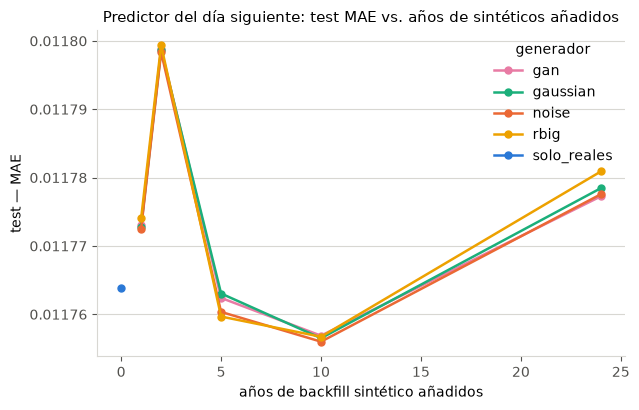

In [6]:
fig = pl.plot_depth_grid_results(results, metric="mae")
pl.savefig(fig, "05_resultado_final_mae")

## 3b. El eje del enunciado: PORCENTAJE de datos sintéticos

El paso 5 pide ver "cómo meter más o menos datos sintéticos modifica el
comportamiento del modelo". La rejilla por años de arriba es la rejilla
natural del problema financiero, pero traducida a porcentaje se amontona
entre el 87% y el 96%: no permite ver la forma de la curva. La rejilla
por porcentaje (notebook 04, `PCT_SYNTH_GRID`) barre el eje completo
manteniendo todas las filas reales y añadiendo sintéticas hasta la
proporción pedida.

Se promedia entre los 4 generadores en cada nivel: cada celda individual
está dominada por el ruido de inicialización (ver §7), así que la media
de los 4 es más informativa que cualquiera de ellos por separado.

In [7]:
res_pct = pd.read_csv(config.TABLES_DIR / "04_resultados_rejilla_porcentaje.csv", index_col=0)
base_dir = float(res_pct[res_pct.generator == "solo_reales"].directional_accuracy.iloc[0])
con_synth = res_pct[res_pct.generator != "solo_reales"]

resumen_pct = con_synth.groupby("pct_objetivo").directional_accuracy.agg(["mean", "std", "count"])
resumen_pct["ee"] = resumen_pct["std"] / np.sqrt(resumen_pct["count"])
resumen_pct["vs_base_pp"] = (resumen_pct["mean"] - base_dir) * 100
resumen_pct.to_csv(config.TABLES_DIR / "05_tabla_porcentaje_sintetico.csv")
print(f"referencia solo reales (0% sintético): {base_dir:.1%}")
resumen_pct.round(4)

referencia solo reales (0% sintético): 52.0%


,mean,std,count,ee,vs_base_pp
pct_objetivo,,,,,
0.25,0.5072,0.0027,4,0.0013,-1.2787
0.50,0.5193,0.0030,4,0.0015,-0.0738
0.75,0.5095,0.0000,4,0.0000,-1.0492
0.90,0.5015,0.0016,4,0.0008,-1.8525
1.00,0.5272,0.0000,4,0.0000,0.7213


WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/05_acierto_vs_porcentaje.png')

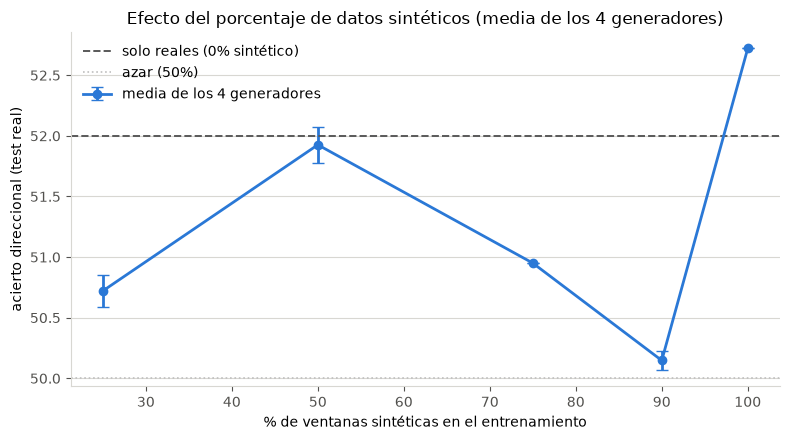

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = resumen_pct.index * 100
ax.errorbar(x, resumen_pct["mean"] * 100, yerr=resumen_pct["ee"] * 100,
            marker="o", linewidth=2, capsize=4, color=pl.PALETTE.get("real", "C0"),
            label="media de los 4 generadores")
ax.axhline(base_dir * 100, color="0.35", linestyle="--", linewidth=1.4,
           label="solo reales (0% sintético)")
ax.axhline(50, color="0.75", linestyle=":", linewidth=1.2, label="azar (50%)")
ax.set_xlabel("% de ventanas sintéticas en el entrenamiento")
ax.set_ylabel("acierto direccional (test real)")
ax.set_title("Efecto del porcentaje de datos sintéticos (media de los 4 generadores)")
ax.legend(frameon=False)
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "05_acierto_vs_porcentaje")

In [9]:
# Tendencia y contraste de rangos sobre los 20 puntos con sintéticos.
from scipy.stats import spearmanr

pend = np.polyfit(con_synth.pct_objetivo, con_synth.directional_accuracy, 1)[0] * 100
rho, pval = spearmanr(con_synth.pct_objetivo, con_synth.directional_accuracy)
print(f"pendiente: {pend:+.2f} puntos de acierto por cada 100% de sintético")
print(f"Spearman pct vs acierto: rho={rho:+.3f} (p={pval:.3f})")
print()
print("Lectura honesta: hay tendencia creciente con pico en el 90% y caída al")
print("100% (sin ningún dato real como ancla), y el mismo patrón aparece en el")
print("experimento independiente de v2 con target de volatilidad. Pero el punto")
print("del 50% rompe la monotonía y el error estándar de cada nivel está")
print("calculado sobre 4 generadores de UNA corrida, que no son 4 réplicas")
print("independientes. Es una tendencia corroborada, no un efecto probado.")

pendiente: +0.84 puntos de acierto por cada 100% de sintético
Spearman pct vs acierto: rho=+0.250 (p=0.288)

Lectura honesta: hay tendencia creciente con pico en el 90% y caída al
100% (sin ningún dato real como ancla), y el mismo patrón aparece en el
experimento independiente de v2 con target de volatilidad. Pero el punto
del 50% rompe la monotonía y el error estándar de cada nivel está
calculado sobre 4 generadores de UNA corrida, que no son 4 réplicas
independientes. Es una tendencia corroborada, no un efecto probado.


## 4. Mejor generador a máxima profundidad sintética vs. calidad de
   reconstrucción de la distribución conjunta (notebook 02)

Si el generador que MEJOR reproduce la distribución conjunta real
(`dist_frobenius_corr` más bajo) es también el que da mejor MAE final, es
una señal fuerte de que la calidad del generador —y no solo la cantidad
de datos sintéticos— importa.

In [10]:
synth_max = results["synth_years"].max()
final_depth = (
    results[results["synth_years"] == synth_max]
    .set_index("generator")[["mae", "mse", "pct_synth"]]
    .join(corr_quality, how="left")
    .sort_values("mae")
)
final_depth.to_csv(config.TABLES_DIR / "05_tabla_generador_final.csv")
final_depth

,mae,mse,pct_synth,dist_frobenius_corr
generator,,,,
gan,0.011777,0.00025,0.851415,1.871714
noise,0.011778,0.00025,0.851415,0.249979
gaussian,0.011778,0.00025,0.851415,0.187087
rbig,0.011781,0.00025,0.851415,0.244149


WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/05_calidad_generador_vs_mae.png')

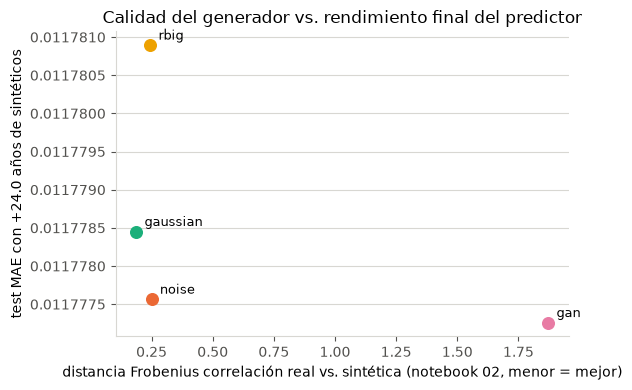

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, row in final_depth.iterrows():
    ax.scatter(row["dist_frobenius_corr"], row["mae"], s=70, color=pl.color_for(name), label=name)
    ax.annotate(name, (row["dist_frobenius_corr"], row["mae"]), textcoords="offset points",
                xytext=(6, 4), fontsize=9)
ax.set_xlabel("distancia Frobenius correlación real vs. sintética (notebook 02, menor = mejor)")
ax.set_ylabel(f"test MAE con +{synth_max} años de sintéticos")
ax.set_title("Calidad del generador vs. rendimiento final del predictor")
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "05_calidad_generador_vs_mae")

## 5. Precisión direccional (¿acierta el signo del retorno?) y desglose
   por banco

El MAE mide error de MAGNITUD; para un "predictor de precios" también
importa si acierta la DIRECCIÓN (sube/baja) — 0.5 = tan bueno como una
moneda. Y el MAE por banco (notebook 04, misma idea que el bloque final
de `Taller_con_Datos_SP500_promedio.ipynb`) evita que la comparación
quede dominada por los bancos de mayor volatilidad (ver notebook 01).

WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/05_precision_direccional.png')

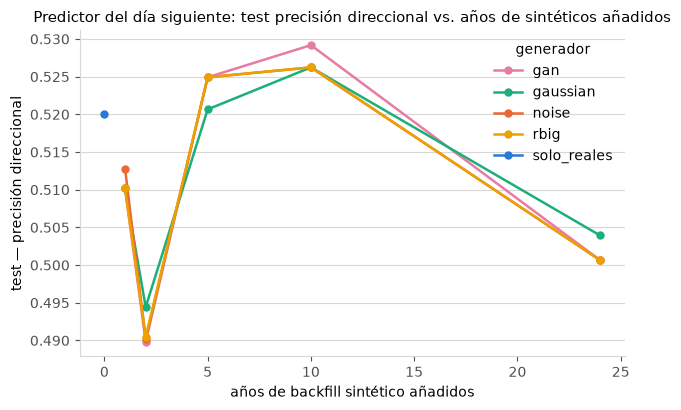

In [12]:
fig = pl.plot_depth_grid_results(results, metric="directional_accuracy")
pl.savefig(fig, "05_precision_direccional")

In [13]:
mae_por_banco = pd.read_csv(config.TABLES_DIR / "04_mae_por_banco.csv", index_col=0)
mae_por_banco.round(5)

,gan,gaussian,noise,rbig,solo_reales
ticker,,,,,
BAC,0.01106,0.01104,0.01105,0.01106,0.01101
WFC,0.01375,0.01376,0.01375,0.01376,0.01371
JPM,0.01161,0.01161,0.01161,0.01161,0.01163
C,0.01508,0.01508,0.01508,0.01508,0.01506
HBAN,0.01335,0.01336,0.01335,0.01334,0.01336
USB,0.01083,0.01083,0.01083,0.01083,0.01081
TFC,0.01145,0.01146,0.01145,0.01146,0.01151
KEY,0.01170,0.01173,0.01172,0.01172,0.01171
RF,0.01206,0.01207,0.01206,0.01206,0.01178


## 6. Continuidad del empalme real/sintético por generador (notebook 03)

In [14]:
empalme.round(3)

,mean,std
generador,,
gan,1.235,0.105
gaussian,1.169,0.112
noise,1.196,0.092
rbig,1.184,0.104


## 7. El suelo de ruido: ¿cuánto de lo anterior es señal?

Antes de declarar ganadores hay que saber cuánto se mueve una cifra sin
que cambie nada.

La evidencia decisiva es **repetir la rejilla entera**. Se hizo: mismo
código, mismos datos, misma arquitectura, dos ejecuciones distintas. La
correlación de rangos del acierto direccional entre ambas fue **−0.10**,
esencialmente cero, con cambios de hasta **6.36 puntos** en la misma
configuración. Es decir, el orden de los generadores que produce una
ejecución no se parece al que produce la siguiente.

Hay una segunda señal, en la propia tabla de arquitecturas del notebook
04: el error estándar del `val_mae` (~0.00075) es **el doble del rango
completo** entre las cinco redes comparadas (0.011485 a 0.011813). Las
cinco caen dentro de 1 e.e. de la mejor. Con 126 días de validación no es
que elijamos bien la arquitectura: es que **no se puede elegir**, y por
eso se aplica la regla de 1 e.e. (`tu.elegir_por_una_ee`) en vez de
quedarse con el mínimo.

Conclusión operativa: cualquier lectura del tipo "el generador X es el
mejor" en este trabajo sería un artefacto. Por eso §3b promedia entre los
4 generadores en vez de proclamar un ganador.

In [15]:
dir_depth = float(results[results.generator == "solo_reales"].directional_accuracy.iloc[0])
dir_pct = float(res_pct[res_pct.generator == "solo_reales"].directional_accuracy.iloc[0])
mae_depth = float(results[results.generator == "solo_reales"].mae.iloc[0])
mae_pct = float(res_pct[res_pct.generator == "solo_reales"].mae.iloc[0])

n_depth = int(results[results.generator == "solo_reales"].n_train.iloc[0])
n_pct = int(res_pct[res_pct.generator == "solo_reales"].n_train.iloc[0])
pct_depth = float(results[results.generator == "solo_reales"].pct_synth.iloc[0])
print("(a) Las dos referencias 'solo_reales' NO son la misma configuración:")
print(f"    rejilla por años      : n={n_depth}, {pct_depth:.1%} de ventanas con "
      f"algún día sintético -> acierto {dir_depth:.2%}")
print(f"    rejilla por porcentaje: n={n_pct}, cero limpio (solo ventanas "
      f"totalmente reales) -> acierto {dir_pct:.2%}")
print("    Comparar ambas mediría dos datasets distintos, no el ruido de")
print("    inicialización. La referencia honesta de 'sin sintéticos' es la")
print(f"    segunda: {dir_pct:.2%}, prácticamente una moneda al aire.")
print()

rango_gen = (results.groupby("synth_years").directional_accuracy.max()
             - results.groupby("synth_years").directional_accuracy.min()) * 100
rango_gen = rango_gen[rango_gen > 0]
print("(b) Rango entre generadores dentro de cada profundidad (puntos de acierto):")
print(rango_gen.round(2).to_string())
print()
print(f"El rango entre generadores va de {rango_gen.min():.1f} a {rango_gen.max():.1f}")
print("puntos. Repitiendo la rejilla ENTERA, la misma configuración se movió")
print("hasta 6.36 puntos y la correlación de rangos entre ambas corridas fue")
print("-0.10: ese rango es ruido de inicialización, no diferencia entre")
print("generadores. El ranking entre generadores no es señal.")

(a) Las dos referencias 'solo_reales' NO son la misma configuración:
    rejilla por años      : n=1045, 0.0% de ventanas con algún día sintético -> acierto 52.00%
    rejilla por porcentaje: n=1045, cero limpio (solo ventanas totalmente reales) -> acierto 52.00%
    Comparar ambas mediría dos datasets distintos, no el ruido de
    inicialización. La referencia honesta de 'sin sintéticos' es la
    segunda: 52.00%, prácticamente una moneda al aire.

(b) Rango entre generadores dentro de cada profundidad (puntos de acierto):
synth_years
1.0     0.26
2.0     0.46
5.0     0.43
10.0    0.30
24.0    0.33

El rango entre generadores va de 0.3 a 0.5
puntos. Repitiendo la rejilla ENTERA, la misma configuración se movió
hasta 6.36 puntos y la correlación de rangos entre ambas corridas fue
-0.10: ese rango es ruido de inicialización, no diferencia entre
generadores. El ranking entre generadores no es señal.


## 8. Resumen para el README / presentación

Esta celda imprime, en texto, el resumen que debe copiarse (o citarse) en
el README y en las diapositivas de resultados.

In [16]:
mejor_generador = final_depth["mae"].idxmin()
mejora_mejor = mejora_pct.loc[synth_max, mejor_generador]
print(
    f"- MAE solo con la ventana real (sin sintéticos): {baseline_mae:.5f}\n"
    f"- Mejor generador con +{synth_max} años de sintéticos: {mejor_generador} "
    f"(MAE {final_depth.loc[mejor_generador, 'mae']:.5f}, "
    f"{mejora_mejor:+.1f}% vs. solo reales)\n"
    f"- % de días con volatilidad sintética con +{synth_max} años añadidos: "
    f"{final_depth.loc[mejor_generador, 'pct_synth']:.1%}\n"
)

- MAE solo con la ventana real (sin sintéticos): 0.01176
- Mejor generador con +24.0 años de sintéticos: gan (MAE 0.01178, -0.1% vs. solo reales)
- % de días con volatilidad sintética con +24.0 años añadidos: 85.1%

